In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import morethemes as mt
mt.set_theme("economist")
import os

In [2]:
# Helper function to categorize professor ranks
def categorize_rank(position):
    pos_lower = position.lower()
    if 'assist' in pos_lower or 'asst' in pos_lower:
        return 'Assistant'
    elif 'assoc' in pos_lower:
        return 'Associate'
    elif 'clinical' in pos_lower or 'clin prof' in pos_lower or 'clin' in pos_lower:
        return 'Clinical'
    elif 'adj' in pos_lower or 'adjunct' in pos_lower:
        return 'Adjunct'
    elif 'vis' in pos_lower or 'visiting' in pos_lower:
        return 'Visiting'
    elif 'act' in pos_lower or 'acting' in pos_lower:
        return 'Acting'
    elif 'prof' in pos_lower:
        return 'Full'
    return 'Other'

# Load all years and categorize
all_data = []
for year in range(2010, 2024):
    file = f"uc_professors_{year}.csv"
    if os.path.exists(file):
        df = pd.read_csv(file)
        df['Rank'] = df['Position'].apply(categorize_rank)
        all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

# Remove Research professors due to data reporting discontinuity in 2013
combined_df = combined_df[combined_df['Rank'] != 'Other']

print(f"Loaded {len(combined_df):,} total professor records (2010-2023)")
print(f"\nRank distribution:")
print(combined_df['Rank'].value_counts())

Loaded 247,033 total professor records (2010-2023)

Rank distribution:
Rank
Full         94707
Assistant    68387
Associate    54211
Clinical     23940
Adjunct       5101
Acting         470
Visiting       217
Name: count, dtype: int64


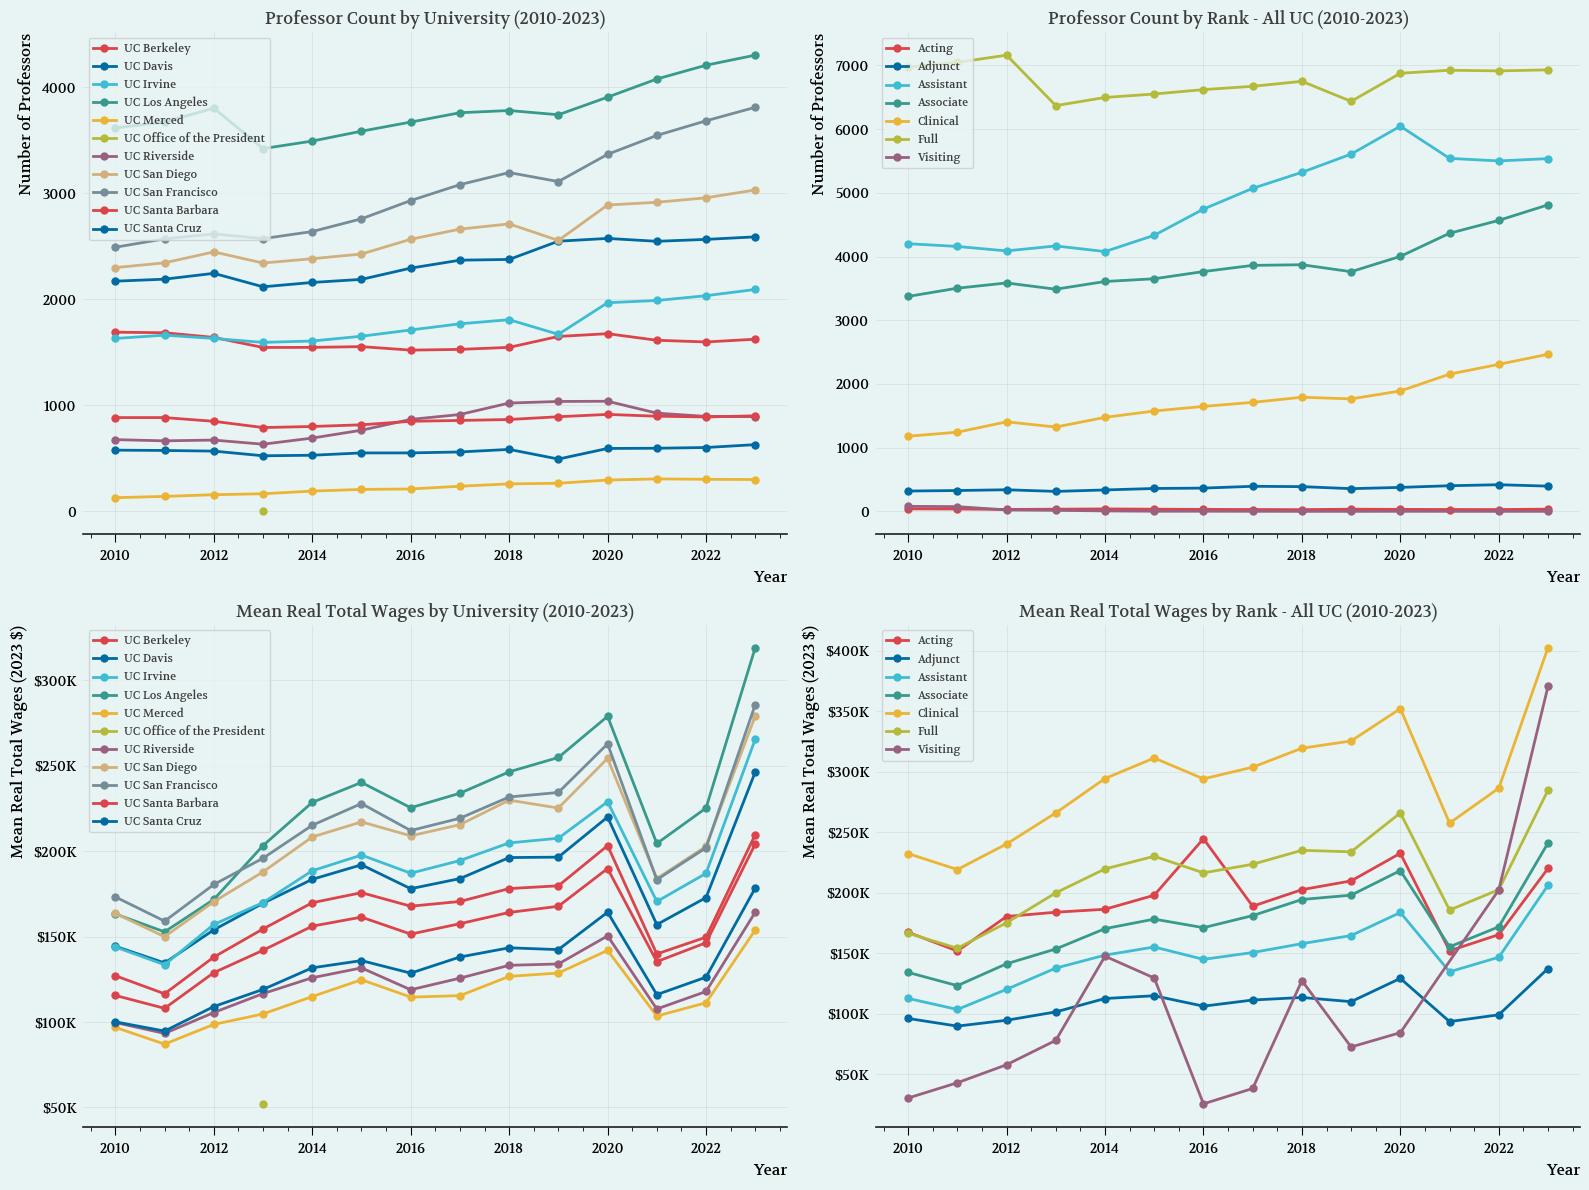

In [3]:
# Create 2x2 subplot figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. TOP LEFT: Professor count by university over time
counts_by_univ = combined_df.groupby(['Year', 'EmployerName']).size().reset_index(name='Count')
universities = sorted(combined_df['EmployerName'].unique())

for univ in universities:
    univ_data = counts_by_univ[counts_by_univ['EmployerName'] == univ]
    short_name = univ.replace('University of California, ', 'UC ')
    ax1.plot(univ_data['Year'], univ_data['Count'], marker='o', linewidth=2, markersize=5, label=short_name)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Number of Professors', fontsize=11)
ax1.set_title('Professor Count by University (2010-2023)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. TOP RIGHT: Professor count by rank over time
counts_by_rank = combined_df.groupby(['Year', 'Rank']).size().reset_index(name='Count')
ranks = sorted(combined_df['Rank'].unique())

for rank in ranks:
    rank_data = counts_by_rank[counts_by_rank['Rank'] == rank]
    ax2.plot(rank_data['Year'], rank_data['Count'], marker='o', linewidth=2, markersize=5, label=rank)

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Number of Professors', fontsize=11)
ax2.set_title('Professor Count by Rank - All UC (2010-2023)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True, alpha=0.3)

# 3. BOTTOM LEFT: Mean real total wages by university over time
wages_by_univ = combined_df.groupby(['Year', 'EmployerName'])['RealTotalWages'].mean().reset_index()

for univ in universities:
    univ_data = wages_by_univ[wages_by_univ['EmployerName'] == univ]
    short_name = univ.replace('University of California, ', 'UC ')
    ax3.plot(univ_data['Year'], univ_data['RealTotalWages'], marker='o', linewidth=2, markersize=5, label=short_name)

ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Mean Real Total Wages (2023 $)', fontsize=11)
ax3.set_title('Mean Real Total Wages by University (2010-2023)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# 4. BOTTOM RIGHT: Mean real total wages by rank over time
wages_by_rank = combined_df.groupby(['Year', 'Rank'])['RealTotalWages'].mean().reset_index()

for rank in ranks:
    rank_data = wages_by_rank[wages_by_rank['Rank'] == rank]
    ax4.plot(rank_data['Year'], rank_data['RealTotalWages'], marker='o', linewidth=2, markersize=5, label=rank)

ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Mean Real Total Wages (2023 $)', fontsize=11)
ax4.set_title('Mean Real Total Wages by Rank - All UC (2010-2023)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8, loc='upper left')
ax4.grid(True, alpha=0.3)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

In [4]:
df.head()

,Year,EmployerName,Position,RegularPay,TotalWages,RealTotalWages,RealRegularPay,Rank
0,2023,"University of California, Berkeley",Act Assoc Prof-Ay,47917,47917,47917.0,47917.0,Associate
1,2023,"University of California, Berkeley",Act Assoc Prof-Ay-B/E/E,60375,97491,97491.0,60375.0,Associate
2,2023,"University of California, Berkeley",Act Asst Prof-Ay,41433,116433,116433.0,41433.0,Assistant
3,2023,"University of California, Berkeley",Act Asst Prof-Ay,95482,155482,155482.0,95482.0,Assistant
4,2023,"University of California, Berkeley",Act Prof-Ay,186662,239687,239687.0,186662.0,Acting


In [5]:
# Regression (in-notebook): log(RegularPay) on Year, Employer, and Rank (2010-2016)
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

# Prepare regression dataframe from the combined dataframe loaded earlier
reg_df = combined_df.copy()
if 'Year' not in reg_df.columns:
    raise ValueError("Column 'Year' not found in `combined_df`. Ensure the source CSVs include a Year column.")
# Restrict to 2010-2016 as requested
reg_df = reg_df[reg_df['Year'].between(2010, 2016)]
# Exclude Visiting ranks per instruction
reg_df = reg_df[reg_df['Rank'] != 'Visiting']
# Keep only observations with positive RegularPay
reg_df = reg_df[reg_df['RegularPay'].notnull() & (reg_df['RegularPay'] > 0)]

print(f"Observations used for regression (2010-2016, excluding Visiting): {len(reg_df):,}")

# Fit OLS with categorical year, employer, and rank indicators; use HC1 robust SEs
formula = 'np.log(RegularPay) ~ C(Year) + C(EmployerName) + C(Rank)'
model = smf.ols(formula=formula, data=reg_df).fit(cov_type='HC1')

# Print the summary inline in the notebook
print(model.summary())

# Also prepare a tidy coefficient table for downstream inspection (kept in-memory)
coef_table = pd.concat([model.params, model.bse, model.tvalues, model.pvalues], axis=1)
coef_table.columns = ['coef','std_err','t','pvalue']
coef_table = coef_table.reset_index().rename(columns={'index':'term'})
regression_results = coef_table
regression_results

Observations used for regression (2010-2016, excluding Visiting): 111,228
                            OLS Regression Results                            
Dep. Variable:     np.log(RegularPay)   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                 1.041e+04
Date:                Tue, 24 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:51:47   Log-Likelihood:            -1.0533e+05
No. Observations:              111228   AIC:                         2.107e+05
Df Residuals:                  111206   BIC:                         2.109e+05
Df Model:                          21                                         
Covariance Type:                  HC1                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]

/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


,term,coef,std_err,t,pvalue
0,Intercept,11.664063,0.026065,447.495215,0.000000e+00
1,C(Year)[T.2011],0.000411,0.007375,0.055705,9.555772e-01
2,C(Year)[T.2012],0.030476,0.007452,4.089882,4.315925e-05
3,C(Year)[T.2013],0.116362,0.006992,16.642780,3.413945e-62
4,C(Year)[T.2014],0.137840,0.007010,19.662899,4.483629e-86
5,C(Year)[T.2015],0.168187,0.007026,23.936769,1.269131e-126
6,C(Year)[T.2016],0.204577,0.006854,29.849028,9.037490e-196
7,"C(EmployerName)[T.University of California, Da...",0.018268,0.007493,2.438203,1.476048e-02
8,"C(EmployerName)[T.University of California, Ir...",-0.035436,0.008212,-4.315357,1.593448e-05
9,"C(EmployerName)[T.University of California, Lo...",0.077172,0.007317,10.546512,5.271794e-26
